In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.datasets import load_iris
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

from sklearn.model_selection import KFold

In [2]:
data = pd.read_csv("all_features_median_after_detrended.csv")

In [3]:
data.columns

Index(['id_star', 'type', 'Period', 'FAP', 'Amplitud', 'Rcs', 'Stetsonk',
       'Mean_variance', 'Autocor_length', 'Con', 'Beyond1Std', 'SmallKurtosis',
       'Std', 'Skew', 'MaxSlope', 'MedianAbsDev', 'MedianBRP',
       'PairSlopeTrend', 'FluxPercentileRatioMid20',
       'FluxPercentileRatioMid35', 'FluxPercentileRatioMid50',
       'FluxPercentileRatioMid65', 'FluxPercentileRatioMid80',
       'PercentDifferenceFluxPercentile', 'PercentAmplitude', 'LinearTrend',
       'Eta_e', 'Mean', 'Q31', 'AndersonDarling', 'Gskew',
       'StructureFunction_index_21', 'StructureFunction_index_31',
       'StructureFunction_index_32', 'Pvar', 'ExcessVar'],
      dtype='str')

In [4]:
#Creating the dependent variable class
factor = pd.factorize(data['type'])
data.type = factor[0]
definitions = factor[1]
print(data.type.head())
print(definitions)

0    0
1    0
2    0
3    0
4    0
Name: type, dtype: int64
Index(['RR', 'CEP', 'EA', 'RRC', 'DCEP-FU', 'DSCT', 'SR', 'E', 'DCEP', 'ACV',
       'DCEPS', 'EB', 'RRAB', 'ED', 'L', 'BL', 'ROT', 'RS', 'RRD', 'HADS',
       'EC', 'EW'],
      dtype='str')


In [5]:
#split the dataset into independent and dependent variables
X = data.drop('type', axis=1).values
y = data['type'].values

In [6]:
print('The independent features set: ')
print(X[:5,:])
print('The dependent variable: ')
print(y[:5])

The independent features set: 
[[ 2.34336330e+008  4.82551446e-001  7.94822315e-306  1.64146000e-001
   1.92117690e-002  8.39912439e-001  5.32211932e-003  3.00000000e+000
   0.00000000e+000  3.09914130e-001 -4.16399048e-001  9.73938723e-002
  -8.74872362e-001  9.95764264e+000  5.07730000e-002  2.85714286e-001
   6.33333333e-001  2.10915254e-001  3.21073565e-001  4.54456099e-001
   6.34140129e-001  8.45281676e-001  1.67012136e-002  1.48103888e-002
   1.33571344e-004  2.74439217e-001  1.82998288e+001  1.39431000e-001
   1.00000000e+000 -1.81836000e-001  1.63565210e+000  2.09726058e+000
   1.32127797e+000  1.00000000e+000  2.06920080e-005]
 [ 4.31589577e+008  3.36103283e-001  0.00000000e+000  1.06353000e-001
   1.96809153e-002  9.05399024e-001  4.27732452e-003  3.00000000e+000
   0.00000000e+000  4.83216237e-001 -1.34771526e+000  7.62290031e-002
  -4.21182562e-002  1.18239916e+001  7.86490000e-002  2.38875878e-001
   4.33333333e-001  3.47333102e-001  5.80904263e-001  7.65819235e-001
   8.

In [7]:
##using k-fold

folds = 10
k_fold = KFold(folds, shuffle=True, random_state=1)

predicted_targets = np.array([])
actual_targets = np.array([])


input_folds = np.empty(folds, dtype=object)
result_folds = np.empty(folds, dtype=object)

fold=0

for train_ix, test_ix in k_fold.split(X):
        train_x, train_y, test_x, test_y = X[train_ix], y[train_ix], X[test_ix], y[test_ix]
        
        
        print('X size: ', X.size)
        print('test_x size: ', test_x.size)

        # Fit the classifier
       # classifier = svm.SVC().fit(train_x, train_y)
    
        # Feature Scaling
        scaler = StandardScaler()
        train_x = scaler.fit_transform(train_x)
        test_x = scaler.transform(test_x)
    
        classifier = RandomForestClassifier(n_estimators = 100, criterion = 'entropy', random_state = 42)
        classifier.fit(train_x, train_y)

        # Predict the labels of the test set samples
        predicted_labels = classifier.predict(test_x)

        predicted_targets = np.append(predicted_targets, predicted_labels)
        actual_targets = np.append(actual_targets, test_y)
        
        
        # instead, save predicted, actual in 2d matrix
        input_folds[fold] = test_y
        result_folds[fold] = predicted_labels
        
        fold=fold+1
        

print('actual')        
print(actual_targets)  
print('predicted')        
print(predicted_targets)       

print('input_folds')        
print(input_folds)
print('result_folds')        
print(result_folds)
        
        
cnf_matrix = confusion_matrix(actual_targets, predicted_targets)


print(cnf_matrix)

X size:  169750
test_x size:  16975
X size:  169750
test_x size:  16975
X size:  169750
test_x size:  16975
X size:  169750
test_x size:  16975
X size:  169750
test_x size:  16975
X size:  169750
test_x size:  16975
X size:  169750
test_x size:  16975
X size:  169750
test_x size:  16975
X size:  169750
test_x size:  16975
X size:  169750
test_x size:  16975
actual
[ 1.  1.  1. ... 21. 21. 21.]
predicted
[16. 16. 16. ... 21. 21. 21.]
input_folds
[array([ 1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
         2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
         2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3,
         3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  4,  5,  5,  5,
         5,  5,  5,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,
         6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,
         6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,
         6,  6,  6,

In [8]:
# here we calculate the scores for all three classes to report the classifier performance

FP = cnf_matrix.sum(axis=0) - np.diag(cnf_matrix) 
FN = cnf_matrix.sum(axis=1) - np.diag(cnf_matrix)
TP = np.diag(cnf_matrix)
TN = cnf_matrix.sum() - (FP + FN + TP)
FP = FP.astype(float)
FN = FN.astype(float)
TP = TP.astype(float)
TN = TN.astype(float)# Sensitivity, hit rate, recall, or true positive rate
TPR = TP/(TP+FN)
# Specificity or true negative rate
TNR = TN/(TN+FP) 
# Precision or positive predictive value
PPV = TP/(TP+FP)
# Negative predictive value
NPV = TN/(TN+FN)
# Fall out or false positive rate
FPR = FP/(FP+TN)
# False negative rate
FNR = FN/(TP+FN)
# False discovery rate
FDR = FP/(TP+FP)
# Overall accuracy for each class
ACC = (TP+TN)/(TP+FP+FN+TN)

print('TPR')
print(TPR)

print('FPR')
print(FPR)

print('ACC')
print(ACC)

TPR
[0.         0.         0.91946309 0.67980296 0.         0.35211268
 0.94455645 0.         0.7012987  0.0952381  0.         0.20661157
 0.93453725 0.01851852 0.06779661 0.         0.68481013 0.
 0.17391304 0.41935484 0.57258065 0.92857143]
FPR
[0.         0.         0.02316602 0.00839251 0.         0.00125549
 0.10627268 0.         0.0035617  0.00041416 0.         0.00422922
 0.01724529 0.00104254 0.00520156 0.         0.05123153 0.
 0.00020717 0.00103756 0.00677105 0.06306546]
ACC
[0.99876289 0.99546392 0.97154639 0.9785567  0.99793814 0.98927835
 0.90412371 0.99835052 0.99175258 0.9956701  0.99876289 0.97608247
 0.97835052 0.98804124 0.94969072 0.98865979 0.9057732  0.99628866
 0.99587629 0.99525773 0.98247423 0.93505155]


/tmp/ipykernel_1339409/1323052776.py:15: RuntimeWarning: invalid value encountered in divide
  PPV = TP/(TP+FP)
/tmp/ipykernel_1339409/1323052776.py:23: RuntimeWarning: invalid value encountered in divide
  FDR = FP/(TP+FP)


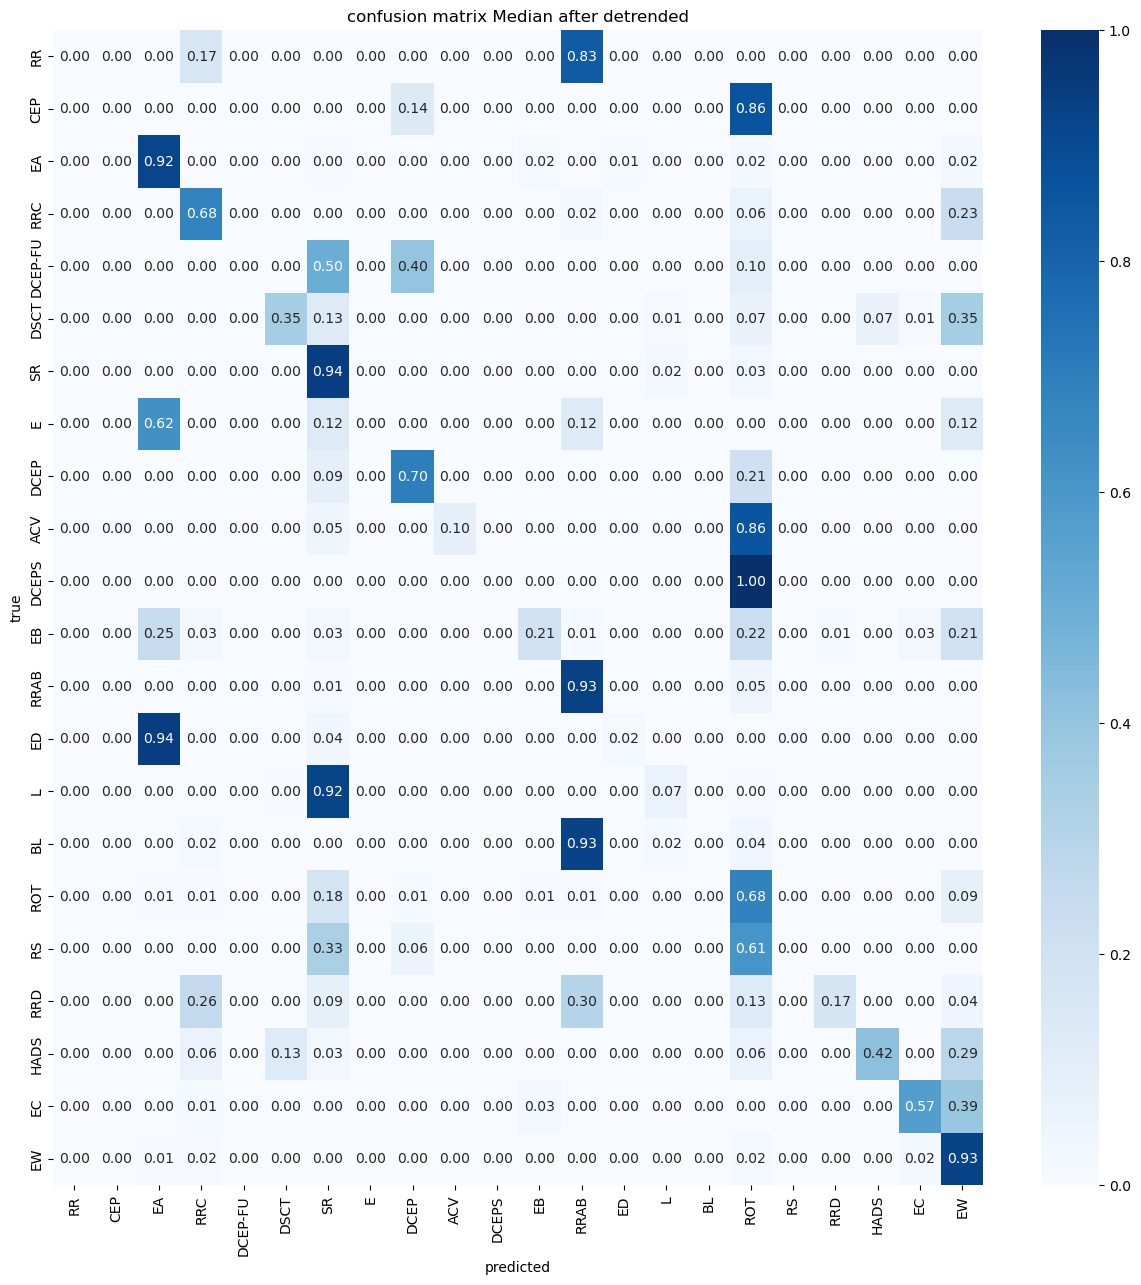

In [12]:


def to_density(cf):
  '''
  This function will take in a confusion matrix cf and return the relative 'density' of every element in each row.
  ---------
  cf: Confusion matrix to be passed in
  '''
  density = []
  n, k = cf.shape
  for i in range(n):
    density_row = []
    for j in range(k):
      total_stars = sum(cf[i])
      density_row.append(cf[i][j]/total_stars)
    density.append(density_row)
  return np.array(density)


def make_confusion_matrix(cf_,
                          xlabel, ylabel,
                          group_names=None,
                          categories_x='auto',
                          categories_y='auto',
                          count=True,
                          cbar=True,
                          xyticks=True,
                          xyplotlabels=True,
                          sum_stats=True,
                          figsize=None,
                          cmap='Blues',
                          title=None,
                          ):
    '''
    This function will make a pretty plot of an sklearn Confusion Matrix cm using a Seaborn heatmap visualization.
    Arguments
    ---------
    cf_:            Confusion matrix to be passed in
    group_names:   List of strings that represent the labels row by row to be shown in each square.
    categories:    List of strings containing the categories to be displayed on the x,y axis. Default is 'auto'
    count:         If True, show the raw number in the confusion matrix. Default is True.
    cbar:          If True, show the color bar. The cbar values are based off the values in the confusion matrix.
                   Default is True.
    xyticks:       If True, show x and y ticks. Default is True.
    xyplotlabels:  If True, show 'True Label' and 'Predicted Label' on the figure. Default is True.
    sum_stats:     If True, display summary statistics below the figure. Default is True.
    figsize:       Tuple representing the figure size. Default will be the matplotlib rcParams value.
    cmap:          Colormap of the values displayed from matplotlib.pyplot.cm. Default is 'Blues'
                   See http://matplotlib.org/examples/color/colormaps_reference.html
                   
    title:         Title for the heatmap. Default is None.
    '''

    cf = to_density(cf_)
    
    # Generate the labels for the matrix elements:
    blanks = ['' for i in range(cf.size)]

    if group_names and len(group_names)==cf.size:
        group_labels = ["{}\n".format(value) for value in group_names]
    else:
        group_labels = blanks

    if count:
        group_counts = ["{0:0.2f}\n".format(value) for value in cf.flatten()]
    else:
        group_counts = blanks

    box_labels = [f"{v1}{v2}".strip() for v1, v2 in zip(group_labels,group_counts)]
    box_labels = np.asarray(box_labels).reshape(cf.shape[0],cf.shape[1])


    # Set figure paramaters:
    if figsize==None:
        #Get default figure size if not set
        figsize = plt.rcParams.get('figure.figsize')

    if xyticks==False:
        #Do not show categories if xyticks is False
        categories=False


    # Make the heatmap:
    plt.figure(figsize=figsize)
    sns.heatmap(cf,annot=box_labels,fmt="",cmap=cmap,cbar=cbar,yticklabels=categories_y,xticklabels=categories_x)

    if xyplotlabels:
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        
    if title:
        plt.title(title)
    plt.title("confusion matrix Median after detrended")
    plt.savefig("confusion_matrix.png", dpi =600)
        

# Make a confusion matrix plot for 10-fold cross-validation:

make_confusion_matrix(cnf_matrix, xlabel='predicted', ylabel='true',categories_x=definitions,categories_y=definitions, count=True, figsize=(15,15))

In [18]:

def heatmap_classification_report(y_true, y_pred, class_names=None, 
                                  title="Classification Report Meidan after Detrended", 
                                  save_path="classification_report_heatmap_median after.png"):
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    df = pd.DataFrame(report).transpose()
    
    # Separar las filas de clases y los promedios (si quieres solo clases)
    # Aquí tomamos solo las filas que corresponden a clases (que tienen 'support' y no son 'accuracy')
    classes_df = df[~df.index.isin(['accuracy', 'macro avg', 'weighted avg'])]
    classes_df = classes_df.drop(columns=['support'])  # opcional: eliminar support para heatmap
    
    plt.figure(figsize=(max(6, len(classes_df.columns)*1.2), max(4, len(classes_df)*0.5)))
    sns.heatmap(classes_df, annot=True, fmt='.3f', cmap='Blues', 
                linewidths=0.5, cbar_kws={'label': 'Score'})
    plt.title(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

/home/ruben/miniconda3/envs/astro/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ruben/miniconda3/envs/astro/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ruben/miniconda3/envs/astro/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

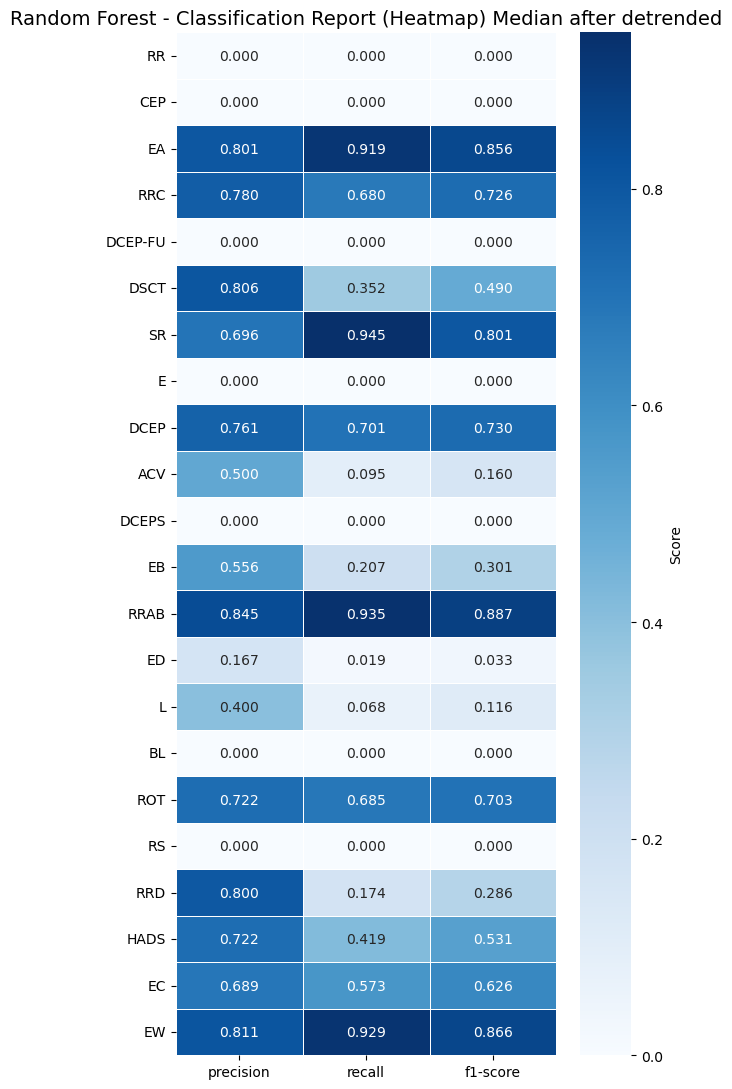

In [19]:
heatmap_classification_report(actual_targets, predicted_targets,
                              class_names=definitions,
                              title="Random Forest - Classification Report (Heatmap) Median after detrended",
                              save_path="classification_report_heatmap_median.png")